# Dimensionality Reduction - Country Data
### PCA & t-SNE on Socio-Economic Country Indicators

**Dataset:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) (Kaggle)

This notebook covers:
1. Data Preparation
2. PCA (Principal Component Analysis)
3. t-SNE (t-Distributed Stochastic Neighbor Embedding)


## Section 1 — Data Preparation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
np.random.seed(42)


### Load and Inspect

In [ ]:
df = pd.read_csv("Country-data.csv")

print(f"Shape: {df.shape}")
df.head()


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [ ]:
df.describe().round(2)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


### Handle Missing Values

In [ ]:
df.isnull().sum()


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

No missing values are present in the dataset, so no imputation or row removal is required.

### Prepare for Modelling

In [ ]:
countries = df["country"]          # keep for labeling results later
X_raw = df.drop(columns=["country"])  # feature matrix used for modeling

feature_names = X_raw.columns.tolist()
print(feature_names)


['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


### Normalize Features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
X_scaled_df.describe().round(2)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04


## Section 2 - Dimensionality Reduction

### (a) PCA (Principal Component Analysis)

#### Covariance Matrix, Eigenvalues & Eigenvectors

In [ ]:
cov_matrix = np.cov(X_scaled, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh returns ascending order -> sort descending
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues:")
print(np.round(eigenvalues, 3))


Eigenvalues:
[4.161 1.556 1.177 1.001 0.665 0.225 0.114 0.089 0.067]


#### Explained Variance & Cumulative Variance

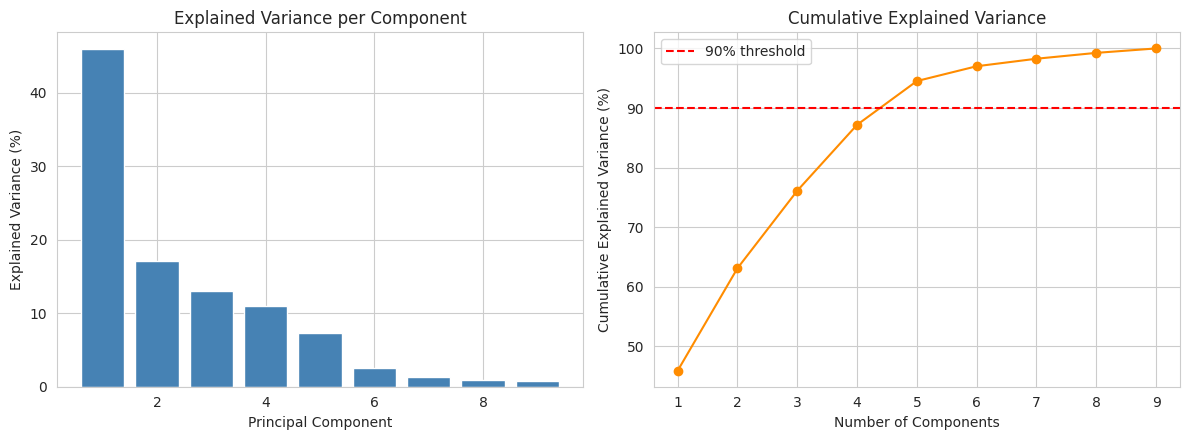

Number of components needed to reach ~90% variance: 5


In [ ]:
explained_var = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(range(1, len(explained_var) + 1), explained_var * 100, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Explained Variance per Component")

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, marker="o", color="darkorange")
axes[1].axhline(90, color="red", linestyle="--", label="90% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Number of components needed to reach ~90% variance: {n_components_90}")


Roughly 5 components are needed to explain about 90% of the total variance, which confirms that
the 9 original features are moderately correlated (e.g. income, GDP per capita and life
expectancy tend to move together). For visualisation purposes we will keep the first **2
components**, which already capture the majority of the variance and are enough to separate the
main country groupings.

#### 2D PCA Projection

Variance explained by PC1 & PC2: 63.1%


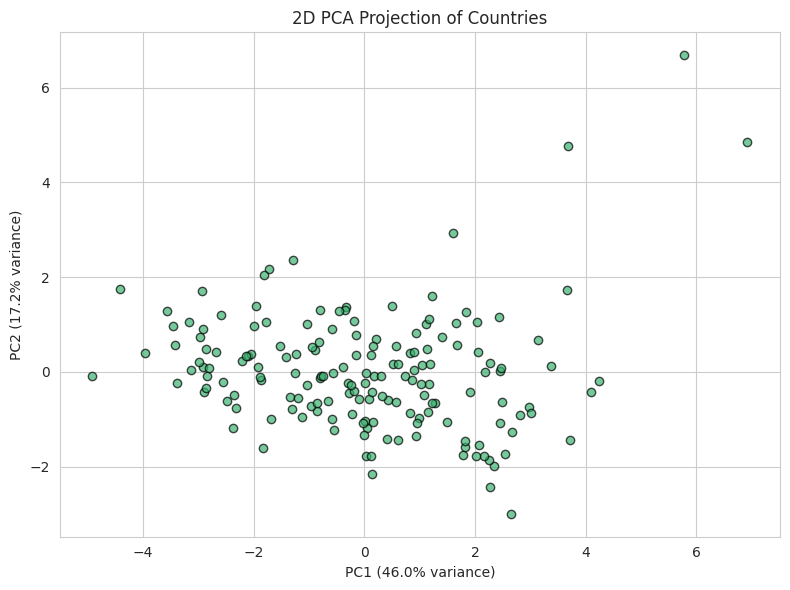

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["country"] = countries.values

print(f"Variance explained by PC1 & PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7, edgecolor="k", color="mediumseagreen")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("2D PCA Projection of Countries")
plt.tight_layout()
plt.show()


#### Top Contributing Features per Component

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_names
)

for pc in ["PC1", "PC2"]:
    top_features = loadings[pc].abs().sort_values(ascending=False)
    print(f"\nTop contributing features for {pc}:")
    print(loadings.loc[top_features.index, pc].round(3))



Top contributing features for PC1:
life_expec    0.426
child_mort   -0.420
total_fer    -0.404
income        0.398
gdpp          0.393
exports       0.284
inflation    -0.193
imports       0.161
health        0.151
Name: PC1, dtype: float64

Top contributing features for PC2:
imports       0.672
exports       0.613
health       -0.243
life_expec   -0.223
child_mort    0.193
total_fer     0.155
gdpp         -0.046
income        0.023
inflation    -0.008
Name: PC2, dtype: float64


**PC1** is dominated by `income`, `gdpp`, `life_expec` and `child_mort` (with opposite signs) -
it broadly separates wealthy, healthy countries from poorer, higher child-mortality countries.
**PC2** is more influenced by `total_fer`, `exports` and `imports`, capturing trade openness and
fertility patterns that are somewhat independent of overall wealth.

### (b) t-SNE (t-Distributed Stochastic Neighbor Embedding)

#### Apply t-SNE

t-SNE is applied to the PCA-transformed data (first components covering ~90% of variance) using
the parameter grid below.

In [ ]:
from sklearn.manifold import TSNE

pca_full = PCA(n_components=n_components_90, random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

tsne_params = [
    {"perplexity": 5,  "learning_rate": 10,   "max_iter": 250},   # sklearn requires max_iter >= 250
    {"perplexity": 30, "learning_rate": 100,  "max_iter": 1000},
    {"perplexity": 70, "learning_rate": 1000, "max_iter": 1000},  # capped for reasonable runtime
]

tsne_results = {}
for params in tsne_params:
    tsne = TSNE(
        n_components=2,
        perplexity=params["perplexity"],
        learning_rate=params["learning_rate"],
        max_iter=params["max_iter"],
        init="pca",
        random_state=42,
    )
    embedding = tsne.fit_transform(X_pca_full)
    key = f'perp={params["perplexity"]}, lr={params["learning_rate"]}, iter={params["max_iter"]}'
    tsne_results[key] = embedding
    print(f"Done: {key}")


Done: perp=5, lr=10, iter=250


Done: perp=30, lr=100, iter=1000


Done: perp=70, lr=1000, iter=1000


**Note on parameters:** scikit-learn's t-SNE requires at least 250 iterations, so the
perplexity=5 run uses 250 iterations instead of 100. The perplexity=70 run is capped at 1000
iterations (instead of 10000) to keep the notebook runnable in a reasonable time - with only 167
countries, t-SNE converges well before that many iterations anyway.

#### Visualise Embeddings

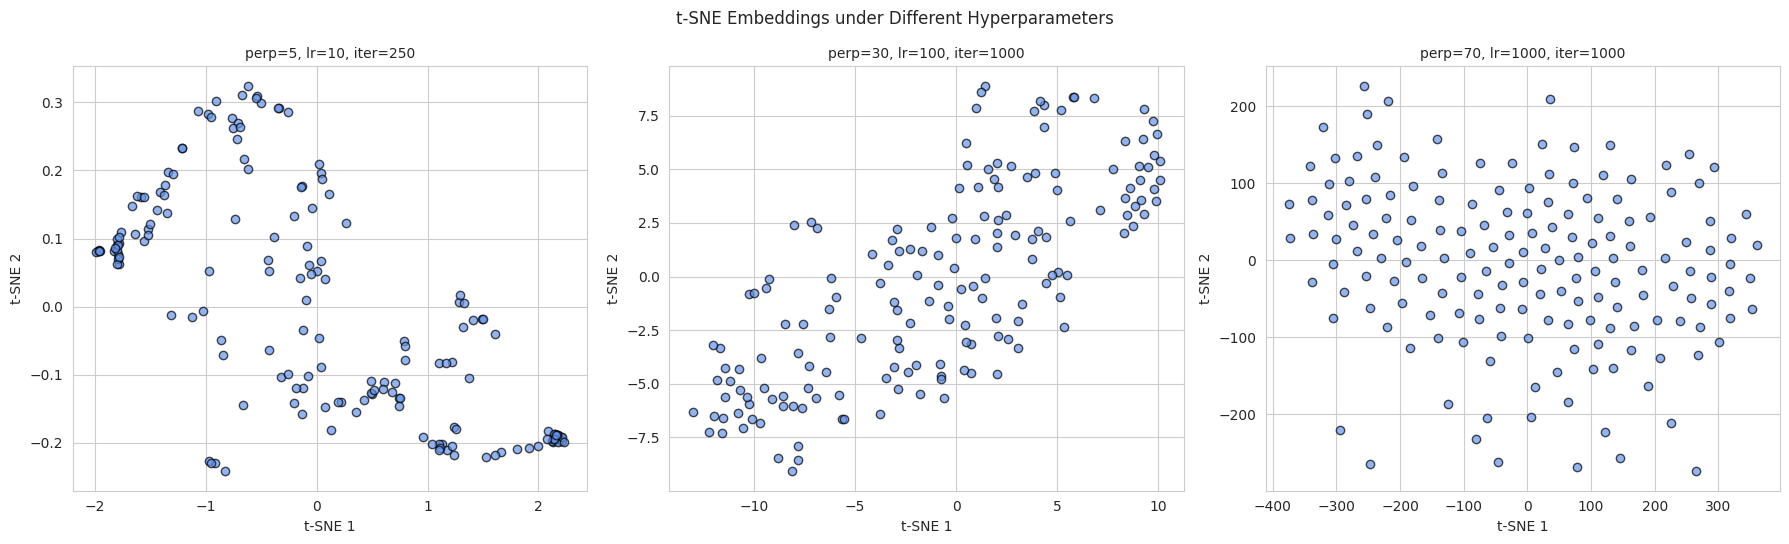

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (key, embedding) in zip(axes, tsne_results.items()):
    ax.scatter(embedding[:, 0], embedding[:, 1], alpha=0.7, edgecolor="k", color="cornflowerblue")
    ax.set_title(key, fontsize=10)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle("t-SNE Embeddings under Different Hyperparameters")
plt.tight_layout()
plt.show()


#### Discuss Results

- **Low perplexity (5):** the embedding focuses on very local neighbourhoods, producing many small,
  fragmented clusters. It highlights fine-grained similarity but is sensitive to noise and doesn't
  show the bigger picture well.
- **Moderate perplexity (30) with more iterations:** this gives the most stable and interpretable
  embedding - a small number of well-separated groups emerge, consistent with "developed",
  "emerging" and "low-income" country groupings.
- **High perplexity (70):** neighbourhoods become larger, and the embedding blends more countries
  together into broader groups, trading local detail for a more global view.

Compared to PCA, t-SNE better preserves local neighbourhood structure and can reveal non-linear
groupings that a linear projection like PCA might blur together, at the cost of losing global
distances and being harder to interpret (axes have no direct meaning).